In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Task 1

In [13]:

Grc_df = pd.read_csv("Grocery_dataset.csv")

rows, columns = Grc_df.shape
print(f"There are {rows} rows and {columns} columns.\n")

print("The first 10 rows:")
print(Grc_df.head(10))
print()
print("The last 10 rows:")
print(Grc_df.tail(10))

Task 2

In [14]:
print(Grc_df.isnull().sum()) # Checks if it is null values and prints it out.
Grc_df.dropna(inplace=True) # Removes the rows with missing values.
print(Grc_df.shape) # Shows the remaining rows and columns.
Grc_df.reset_index(drop=True, inplace=True) # Cleans up the index after removal
print(Grc_df.isnull().sum()) # Confirms no missing values remain.

Task 3

In [15]:
print(f"{Grc_df["Outlet_Size"].unique()}\n")
print(f"There are {Grc_df["Outlet_Size"].nunique()} unique rows\n")
print("Small is the minimum size and High is the maximum size")

Task 4

In [16]:
print(Grc_df["Item_Fat_Content"].unique()) # Shows all unique values in Item_Fat coloumn.
print(Grc_df["Item_Fat_Content"].nunique()) # Counts all unique values


# Fixes inconsistent writing methods.
Grc_df['Item_Fat_Content'] = Grc_df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

# Confirms that it is fixed
print(Grc_df['Item_Fat_Content'].unique())
print(Grc_df['Item_Fat_Content'].nunique())

Task 5

In [17]:
Grc_new_df = Grc_df.drop(Grc_df.columns[[0,6]], axis='columns')
print(Grc_new_df.head)

Task 6

In [18]:
outletTypes = Grc_new_df['Outlet_Type'].unique()
print(outletTypes)
SupType_1 = Grc_new_df[Grc_new_df['Outlet_Type'] == outletTypes[0]].copy()
SupType_2 = Grc_new_df[Grc_new_df['Outlet_Type'] == outletTypes[1]].copy()
print(SupType_1)
print(SupType_2)

Task 7

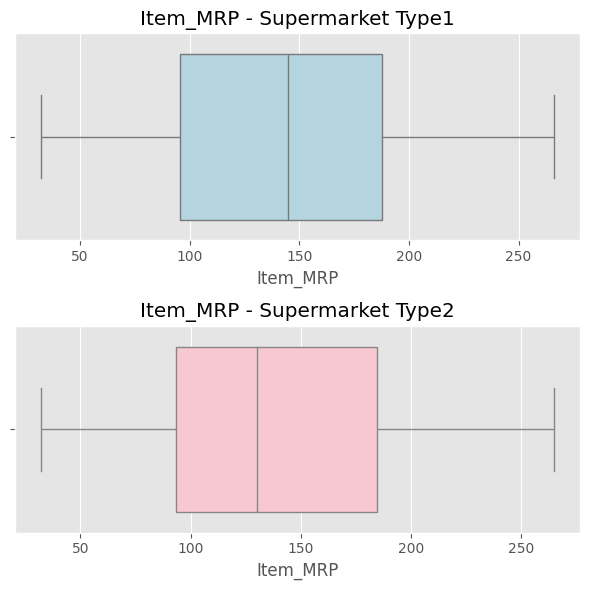

Median MRP - Type1: 144.6102
Median MRP - Type2: 130.18099999999998


In [19]:
plt.style.use('ggplot')

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

sns.boxplot(x=SupType_1['Item_MRP'], ax=axes[0], color='lightblue')
axes[0].set_title('Item_MRP - Supermarket Type1')

sns.boxplot(x=SupType_2['Item_MRP'], ax=axes[1], color='pink')
axes[1].set_title('Item_MRP - Supermarket Type2')

plt.tight_layout()
plt.show()

print("Median MRP - Type1:", SupType_1['Item_MRP'].median())
print("Median MRP - Type2:", SupType_2['Item_MRP'].median())
print("There are no outliers")

Task 8

In [20]:
# Combines SupType_1 and SupType_2
Grc_Concat_df = pd.concat([SupType_1, SupType_2])

# Sort the values based in Item_Outlet_Sales in ascending order. From lowest to highest.
Grc_Concat_df = Grc_Concat_df.sort_values(by='Item_Outlet_Sales')

# Shows the store with the lowest sales.head(1) chooses the first row from the sort.
print(Grc_Concat_df[['Item_Outlet_Sales', 'Outlet_Location_Type']].head(1))

      Item_Outlet_Sales Outlet_Location_Type
1277             73.238               Tier 3


The store with the lowest sales (Item_Outlet_Sales = 73.238) has Outlet_Location_Type = Tier 3

Task 9

In [ ]:
# Creates a Multindex based on Outlet_Size and Outlet_Location_Type-
Grc_Concat_df = Grc_Concat_df.set_index(['Outlet_Size', 'Outlet_Location_Type'])

# Show the results.
Grc_Concat_df.head()

Task 10